### Random Forest and Boosting Models
1. Load cleaned data
2. Train-test split
3. Random Forest model
4. Gradient Boosting model
5. Model comparison


In [20]:
# Load and prepare data 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor


df = pd.read_csv("../data/processed/berlin_2024_Q1_clean.csv")

y = df["log_price"]
X = df.drop(columns=["price", "log_price"])

X = pd.get_dummies(X, drop_first=True)
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# Random forest model
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

rmse_rf, r2_rf


(np.float64(0.44561374669845516), 0.5600494991693632)

In [22]:
# Gradient Boosting

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

rmse_gbr, r2_gbr


(np.float64(0.44506308605027795), 0.5611361520969675)

In [23]:
# Random Feature Importance for random forest
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance.head(10)


accommodates              0.256558
latitude                  0.163642
longitude                 0.159580
number_of_reviews         0.075281
review_scores_rating      0.063038
bathrooms                 0.061595
room_type_Private room    0.054007
room_type_Hotel room      0.053134
bedrooms                  0.034793
room_type_Shared room     0.029164
dtype: float64

<Axes: title={'center': 'Random Forest – Top 10 Features'}>

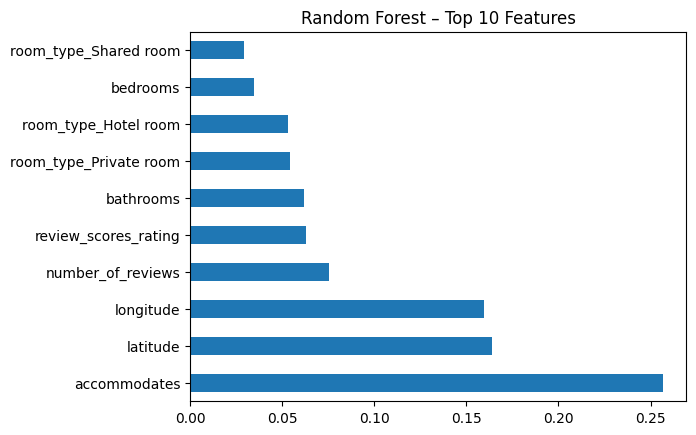

In [29]:
rf_importance.head(10).plot(kind="barh", title="Random Forest – Top 10 Features")


In [24]:
# Feature Importance for gradient boosting

gbr_importance = pd.Series(
    gbr.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

gbr_importance.head(10)


accommodates              0.340822
bedrooms                  0.106586
longitude                 0.093611
room_type_Hotel room      0.093502
room_type_Private room    0.080411
bathrooms                 0.064366
latitude                  0.059088
room_type_Shared room     0.044268
kitchen                   0.038398
air_conditioning          0.028115
dtype: float64

<Axes: title={'center': 'Gradient Boosting – Top 10 Features'}>

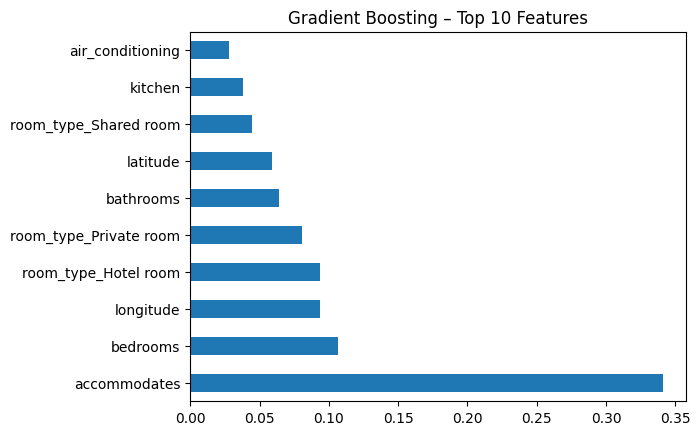

In [25]:
# Ploting the gradient boosting feature importance
gbr_importance.head(10).plot(kind="barh", title="Gradient Boosting – Top 10 Features")


Looking at feature importance, both the Random Forest and Gradient Boosting models tell a very similar story. The most important factors driving prices are related to how many people a listing can accommodate and its overall size, which makes intuitive sense for short-term rentals. Location also ranks high in both models, reflecting price differences across neighborhoods. Room type clearly matters as well: hotel-style listings tend to be more expensive, while private and shared rooms are generally priced lower. Amenities such as having a kitchen or air conditioning do have a positive effect on prices, but their influence is smaller compared to size and location. The fact that both models highlight the same key drivers increases confidence that these results reflect real pricing patterns rather than model-specific artifacts.

In [26]:
# Horserace

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

# OLS results (from Notebook 02)
rmse_ols = 0.5113168405059069
r2_ols = 0.421

# LASSO results (from Notebook 02)
rmse_lasso = 0.5113168405059069
r2_lasso = 0.4207489228630794


In [27]:
# Plot the table
results = pd.DataFrame({
    "Model": ["OLS", "LASSO", "Random Forest", "Gradient Boosting"],
    "RMSE": [rmse_ols, rmse_lasso, rmse_rf, rmse_gbr],
    "R_squared": [r2_ols, r2_lasso, r2_rf, r2_gbr]
})

results

,Model,RMSE,R_squared
0,OLS,0.511317,0.421000
1,LASSO,0.511317,0.420749
2,Random Forest,0.445614,0.560049
3,Gradient Boosting,0.445063,0.561136


The horserace comparison shows a clear performance gap between linear and nonlinear models. OLS and LASSO explain approximately 42% of the variation in log Airbnb prices, while Random Forest and Gradient Boosting increase explanatory power to around 56%. The improvement suggests that Airbnb pricing exhibits nonlinear relationships and interaction effects that are better captured by tree-based methods. Among all models, Gradient Boosting performs best, although the difference relative to Random Forest is small.